In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


In [ ]:
# Set your paths
BASE_DIR = '/Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/dataset_final'  # Change this to your dataset path
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')

# Model parameters (optimized for Raspberry Pi)
IMG_SIZE = 96  # Smaller size for faster inference on RPi
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 5
CLASS_NAMES = ['bear', 'elephant', 'leopard', 'other2', 'tiger']

print(f"\nConfiguration:")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Classes: {CLASS_NAMES}")



Configuration:
Image Size: 96x96
Batch Size: 32
Epochs: 10
Classes: ['bear', 'elephant', 'leopard', 'other2', 'tiger']


In [42]:

print("\n" + "="*60)
print("PREPARING DATA")
print("="*60)

# Data augmentation for training (helps prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Only rescaling for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load validation data
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nFound {train_generator.samples} training images")
print(f"Found {val_generator.samples} validation images")
print(f"Class indices: {train_generator.class_indices}")



PREPARING DATA
Found 11103 images belonging to 6 classes.
Found 4083 images belonging to 6 classes.

Found 11103 training images
Found 4083 validation images
Class indices: {'bear': 0, 'elephant': 1, 'leopard': 2, 'other': 3, 'other2': 4, 'tiger': 5}


In [43]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load validation data
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print class indices
print("\nClass Indices:")
print(train_generator.class_indices)
print(f"\nTotal Training Images: {train_generator.samples}")
print(f"Total Validation Images: {val_generator.samples}")

Found 11103 images belonging to 6 classes.
Found 4083 images belonging to 6 classes.

Class Indices:
{'bear': 0, 'elephant': 1, 'leopard': 2, 'other': 3, 'other2': 4, 'tiger': 5}

Total Training Images: 11103
Total Validation Images: 4083



VISUALIZING SAMPLE IMAGES


IndexError: list index out of range

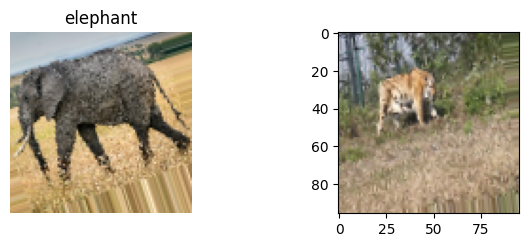

In [44]:
print("\n" + "="*60)
print("VISUALIZING SAMPLE IMAGES")
print("="*60)

# Get a batch of images
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    class_idx = np.argmax(sample_labels[i])
    plt.title(CLASS_NAMES[class_idx])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
print("Sample images saved as 'sample_images.png'")
plt.show()


In [20]:

num_classes = len(train_generator.class_indices)

# Load pre-trained MobileNetV2 (without top layer)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers (we'll only train the top layers)
base_model.trainable = False

# Build complete model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

print("\nTraining Complete!")


Starting Training...

1388/1388 ━━━━━━━━━━━━━━━━━━━━ 167s 119ms/step - accuracy: 0.9585 - loss: 0.1278 - val_accuracy: 0.9929 - val_loss: 0.0187

Training Complete!


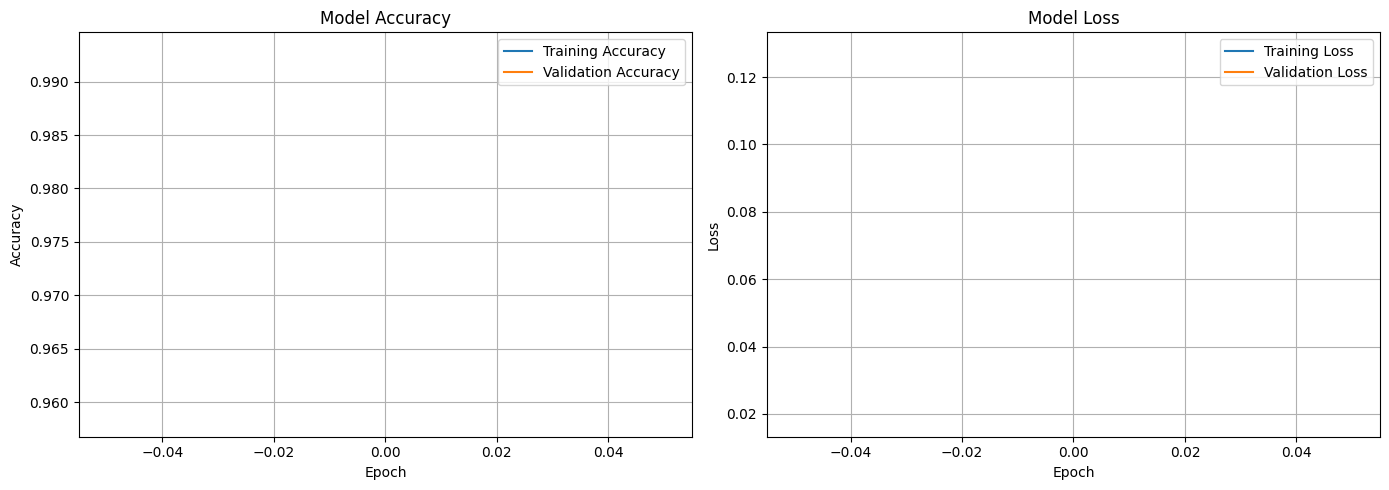

In [23]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [24]:
print("\n" + "="*50)
print("Evaluating Model...")
print("="*50 + "\n")

# Get predictions
val_generator.reset()
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



Evaluating Model...

511/511 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step

Classification Report:


ValueError: Number of classes, 5, does not match size of target_names, 6. Try specifying the labels parameter

In [ ]:
print("\n" + "="*50)
print("Fine-tuning Model (Unfreezing some layers)...")
print("="*50 + "\n")

# Unfreeze the last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train for a few more epochs
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    verbose=1
)

plot_training_history(history_fine)

In [ ]:
model.save('animal_classifier_model.h5')
print("\n✓ Model saved as 'animal_classifier_model.h5'")

# Save in TensorFlow Lite format (optimized for Raspberry Pi)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('animal_classifier.tflite', 'wb') as f:
    f.write(tflite_model)
print("✓ TFLite model saved as 'animal_classifier.tflite'")

# Save class names
with open('class_names.txt', 'w') as f:
    for class_name in class_names:
        f.write(f"{class_name}\n")
print("✓ Class names saved as 'class_names.txt'")

print("\n" + "="*50)
print("All models saved successfully!")
print("="*50)